# Практическая работа 10: Иерархическая кластеризация | `Hepta`

## 1. Импорты и конфигурация

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 11
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

NOTEBOOK_DIR = Path.cwd()
HEPTA_PATH = NOTEBOOK_DIR / "hepta.csv"

HEPTA_PATH

PosixPath('/Users/mikhail/Developer/SUSU.PE/СП-М-О-ИАД-2025/Практика/Практика 10 - Иерархическая кластеризация/hepta.csv')

## 2. Описание данных

В практической работе используется benchmark-набор `Hepta`, представляющий собой трехмерную
выпуклую кластерную структуру с семью естественными группами наблюдений. Данный набор удобен
для визуального сопоставления дендрограмм, построенных различными стратегиями агрегации.

## 3. Загрузка датасета

In [2]:
def load_dataset(path: Path) -> pd.DataFrame:
    """Загружает CSV-файл с benchmark-набором данных.

    Parameters
    ----------
    path : Path
        Путь к CSV-файлу с данными.

    Returns
    -------
    pd.DataFrame
        Таблица наблюдений в исходной структуре CSV-файла.
    """
    return pd.read_csv(path)

In [3]:
hepta_df = load_dataset(HEPTA_PATH)

In [4]:
pd.DataFrame(
    [
        {
            "dataset": "Hepta",
            "n_objects": len(hepta_df),
            "n_features": len([column for column in hepta_df.columns if column.startswith("x")]),
            "n_reference_clusters": hepta_df["true_cluster"].nunique(),
        }
    ]
)

,dataset,n_objects,n_features,n_reference_clusters
0,Hepta,212,3,7


In [5]:
hepta_df.head()

,object_id,x1,x2,x3,true_cluster
0,1,-0.0633,0.0277,0.0227,1
1,2,-0.0007,0.0482,0.0692,1
2,3,-0.0608,-0.0091,0.0531,1
3,4,0.0133,-0.0119,0.0553,1
4,5,-0.0545,-0.0038,0.0017,1


In [6]:
hepta_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   object_id     212 non-null    int64  
 1   x1            212 non-null    float64
 2   x2            212 non-null    float64
 3   x3            212 non-null    float64
 4   true_cluster  212 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 8.4 KB


## 4. Подготовка данных и вспомогательные функции

In [7]:
def standardize_features(
    data: pd.DataFrame,
    feature_columns: list[str],
) -> tuple[pd.DataFrame, StandardScaler]:
    """Стандартизует признаки набора данных.

    Parameters
    ----------
    data : pd.DataFrame
        Исходная таблица наблюдений.
    feature_columns : list[str]
        Список стандартизируемых признаков.

    Returns
    -------
    tuple[pd.DataFrame, StandardScaler]
        Стандартизованная таблица и использованный объект scaler.
    """
    scaler = StandardScaler()
    transformed = data.copy()
    transformed[feature_columns] = scaler.fit_transform(transformed[feature_columns])
    return transformed, scaler

In [8]:
def plot_reference_clusters_3d(
    data: pd.DataFrame,
    feature_columns: list[str],
    labels: np.ndarray,
    figure_title: str,
) -> None:
    """Строит трехмерную диаграмму эталонной кластерной структуры.

    Parameters
    ----------
    data : pd.DataFrame
        Набор данных для визуализации.
    feature_columns : list[str]
        Используемые признаки.
    labels : np.ndarray
        Метки эталонных кластеров.
    figure_title : str
        Заголовок рисунка.
    """
    figure = plt.figure(figsize=(8, 6))
    axis = figure.add_subplot(111, projection="3d")
    palette = sns.color_palette("tab10", n_colors=12)
    colors = [palette[int(label) % len(palette)] for label in labels]

    axis.scatter(
        data[feature_columns[0]],
        data[feature_columns[1]],
        data[feature_columns[2]],
        c=colors,
        s=20,
        alpha=0.85,
    )
    axis.set_xlabel(feature_columns[0])
    axis.set_ylabel(feature_columns[1])
    axis.set_zlabel(feature_columns[2])
    axis.set_title(figure_title)
    plt.tight_layout()
    plt.show()

In [9]:
def plot_dendrogram_panel(
    data: pd.DataFrame,
    feature_columns: list[str],
    methods: list[str],
    figure_title: str,
) -> None:
    """Строит панель дендрограмм для нескольких стратегий агрегации.

    Parameters
    ----------
    data : pd.DataFrame
        Набор данных.
    feature_columns : list[str]
        Используемые признаки.
    methods : list[str]
        Перечень стратегий агрегации (`single`, `complete`, `average`, `ward`).
    figure_title : str
        Заголовок панели дендрограмм.
    """
    X = data[feature_columns].to_numpy()
    method_titles = {
        "single": "Single linkage",
        "complete": "Complete linkage",
        "average": "Group average",
        "ward": "Ward",
    }

    figure, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()

    for axis, method in zip(axes, methods):
        linkage_matrix = linkage(X, method=method, optimal_ordering=True)
        dendrogram(linkage_matrix, ax=axis, color_threshold=None, no_labels=True)
        axis.set_title(method_titles[method])
        axis.set_xlabel("Наблюдения")
        axis.set_ylabel("Высота объединения")

    figure.suptitle(figure_title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

### 4.1. Стандартизация признакового пространства набора `Hepta`

In [10]:
hepta_scaled_df, hepta_scaler = standardize_features(hepta_df, ["x1", "x2", "x3"])

### 4.2. Визуальный анализ эталонной кластерной структуры

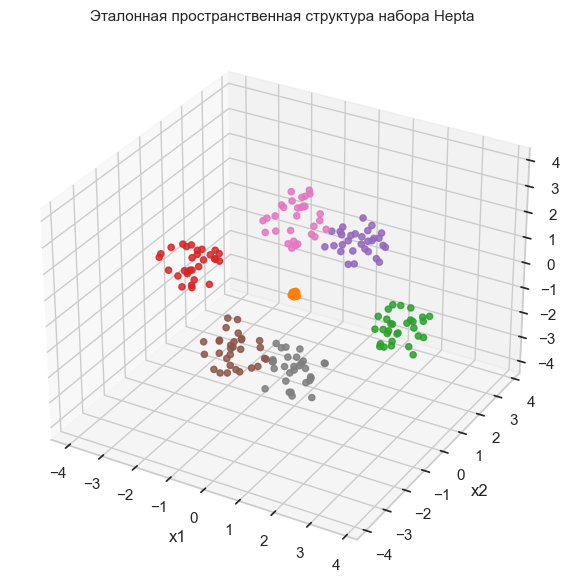

In [11]:
plot_reference_clusters_3d(
    data=hepta_df,
    feature_columns=["x1", "x2", "x3"],
    labels=hepta_df["true_cluster"].to_numpy(),
    figure_title="Эталонная пространственная структура набора Hepta",
)

## 5. Эксперименты

### 5.1. Построение дендрограмм для различных стратегий агрегации

Иерархическая кластеризация проводится на стандартизованном наборе `Hepta`.
Рассматриваются методы `single`, `complete`, `average` и `ward`. Полученные дендрограммы
позволяют сопоставить различия в последовательности объединения наблюдений и в высотах слияния кластеров.

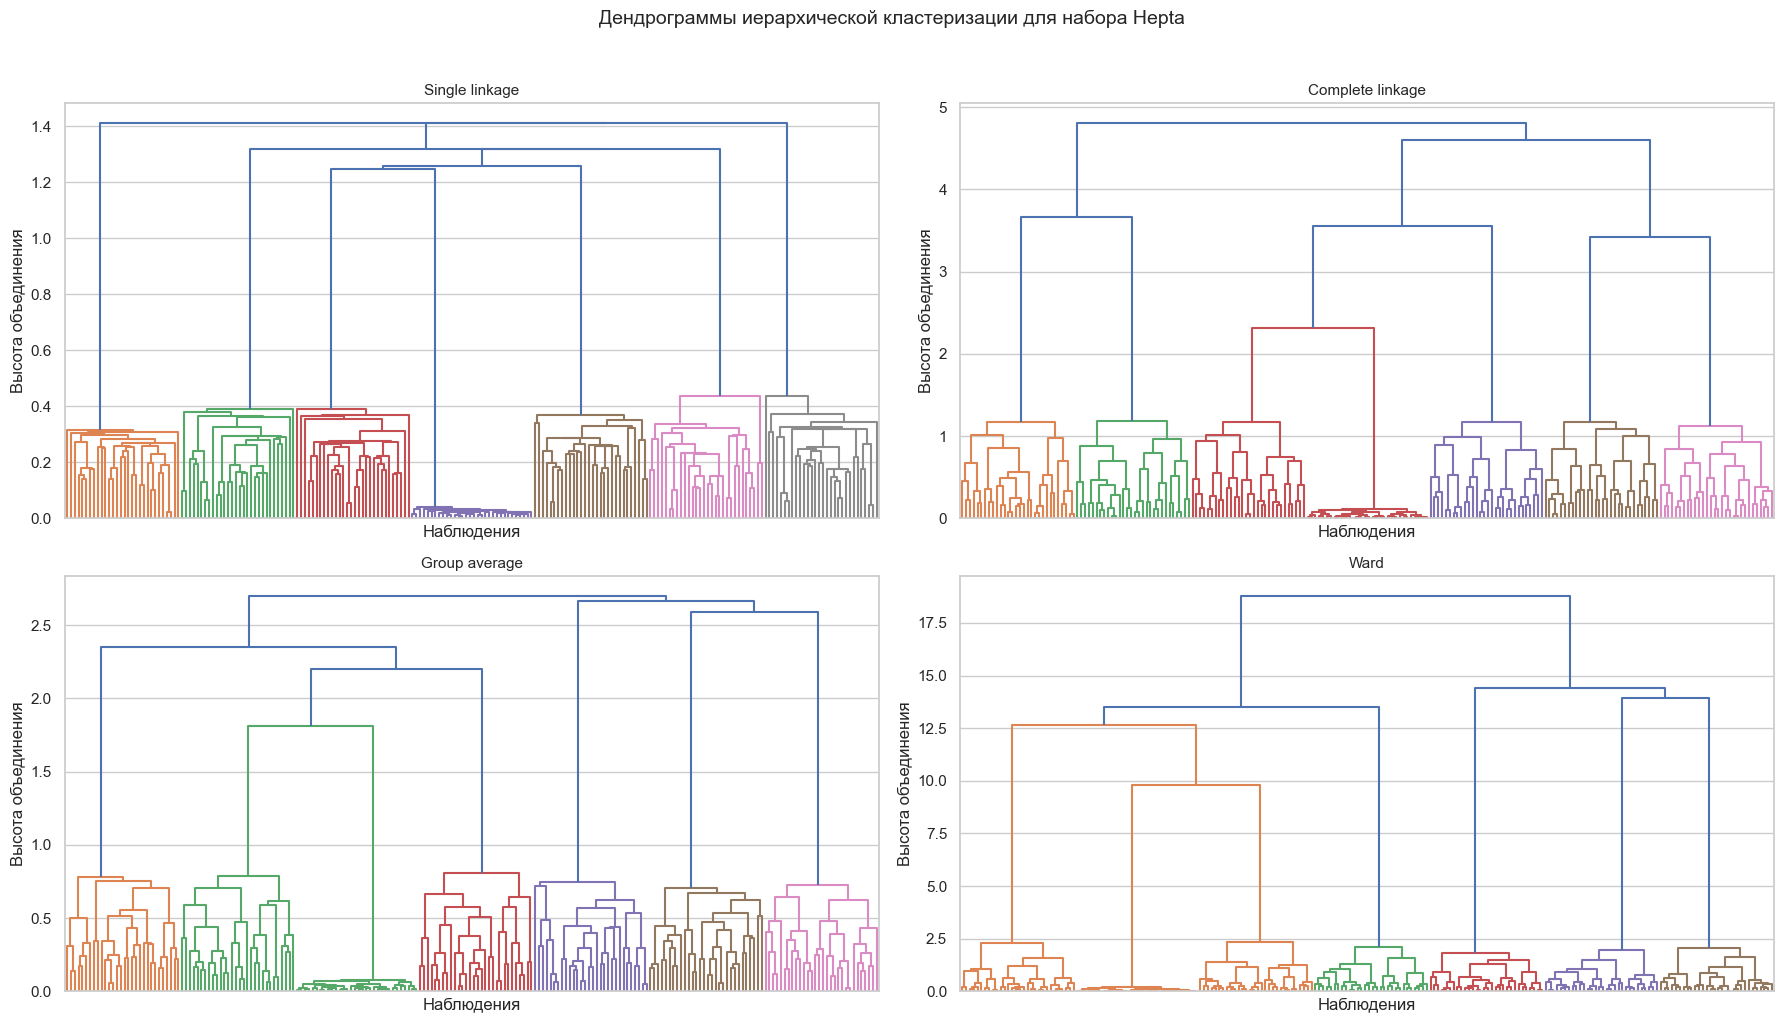

In [12]:
plot_dendrogram_panel(
    data=hepta_scaled_df,
    feature_columns=["x1", "x2", "x3"],
    methods=["single", "complete", "average", "ward"],
    figure_title="Дендрограммы иерархической кластеризации для набора Hepta",
)

## 6. Вывод

Построенные дендрограммы показывают, что разные стратегии агрегации по-разному формируют дерево
иерархических объединений даже на одном и том же наборе данных. Это позволяет визуально сопоставить
особенности методов `single`, `complete`, `average` и `ward` при анализе выпуклой кластерной структуры набора `Hepta`.